# **Curso intermedio de SQL**


---

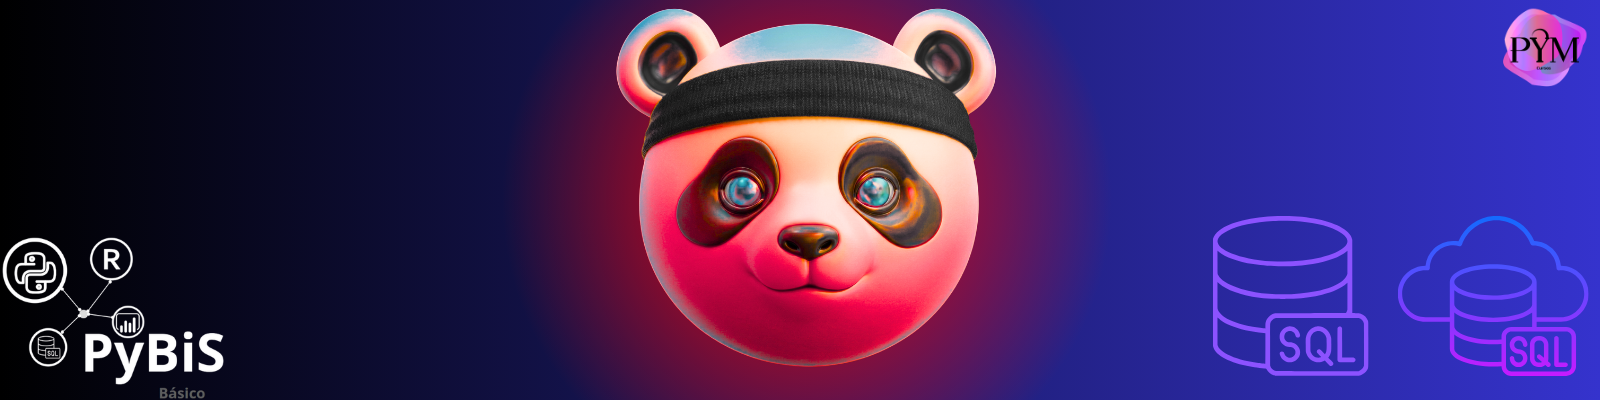

---

In [1]:
import random as r
import pandas as pd
import datetime as dt
import sqlite3 as sql

ruta_drive = "/content/drive/MyDrive/PyM-Cursos/Logística Cursos/_Curso SQL/Ventas_Historico.db"

In [3]:
# @title Configuracion del entorno
#_______________________________________________________________________________
# Funcion para generar un dataframe con las ventas historicas
# y subirlo directamente a la base de datos

# ✅ Esta funcion simula un flujo de datos
# ✅ Esta funcion automatiza la generación de la informacion
#_______________________________________________________________________________
def generar_df_info_mejorada(
    fechaVenta,
    root_base_datos = ruta_drive,
    nombreTablaSql = "Consol_Ventas",
    # replace o append
    r_o_a = "append",
    verbose=False
    ):
  # Lista 1: Productos típicos de papelería grande
  listaInsumosProductos = [
      "Cuaderno profesional", "Cuaderno doble raya", "Lápiz del número 2", "Pluma azul",
      "Pluma negra", "Pluma roja", "Marcador permanente", "Marcador para pizarrón",
      "Resaltador amarillo", "Resaltador verde", "Resaltador rosa", "Goma de borrar",
      "Sacapuntas", "Tijeras escolares", "Tijeras de oficina", "Regla de 30 cm",
      "Compás metálico", "Juego de geometría", "Pegamento en barra", "Pegamento líquido",
      "Cinta adhesiva", "Corrector líquido", "Corrector en cinta", "Carpeta tamaño carta",
      "Carpeta tamaño oficio", "Separadores de plástico", "Hojas blancas tamaño carta",
      "Hojas recicladas", "Hojas cuadriculadas", "Post-it", "Bloc de notas",
      "Engrapadora", "Caja de grapas", "Clips metálicos", "Broches tipo baco",
      "Folder manila", "Folder plástico con broche", "Archivador", "Tóner para impresora",
      "Cartuchos de tinta", "Calculadora científica", "Calculadora básica", "Memoria USB",
      "Mouse inalámbrico", "Teclado", "Agenda anual", "Calendario de escritorio",
      "Papel fotográfico", "Papel bond", "Cinta doble cara", "Pega diamantina"
  ]

  # Lista 2: 10 nombres completos (5 hombres, 5 mujeres)
  listaInsumosCajeros = [
      "Juan Carlos Ramírez López", "Miguel Ángel Torres Hernández", "José Luis González Cruz",
      "Carlos Alberto Mendoza Pérez", "Luis Fernando Ortega Díaz",
      "María Fernanda Castillo Reyes", "Ana Sofía Morales García", "Valeria Jiménez Flores",
      "Diana Carolina Salazar Ruiz", "Paola Alejandra Vargas León"
  ]

  # Lista 3: 10 zonas de la Ciudad de México
  listaInsumosSucursales = [
      "Centro Histórico", "Polanco", "Santa Fe", "Coyoacán", "Cuemanco",
      "Tlalpan", "Xochimilco", "La Condesa", "Reforma", "San Ángel"
  ]

  ####################################################
  # Zona de definicion de listas vacías
  ####################################################
  listaInsumoV_fecha = []
  listaInsumoV_cajero = []
  listaInsumoV_producto = []
  listaInsumoV_precio = []
  listaInsumoV_cantidad = []
  listaInsumoV_total = []
  listaInsumoV_sucursal = []

  # Implementamos un bucle for para simular, por ejemplo, 1000 ventas
  for i in range(1, r.randint(1000, 35001)):
    ####################################################
    # Zona de definicion de variables
    ####################################################

    cajero = r.choice(listaInsumosCajeros)
    producto = r.choice(listaInsumosProductos)
    precio = round(r.randint(10, 20000) * r.random(), 2)
    cantidad = r.randint(1, 100)
    total = round(precio * cantidad, 2)
    sucursal = r.choice(listaInsumosSucursales)

    ####################################################
    # Zona de alimentacion de las listas
    ####################################################
    listaInsumoV_fecha.append(fechaVenta)
    listaInsumoV_cajero.append(cajero)
    listaInsumoV_producto.append(producto)
    listaInsumoV_precio.append(precio)
    listaInsumoV_cantidad.append(cantidad)
    listaInsumoV_total.append(total)
    listaInsumoV_sucursal.append(sucursal)

  # Construimos entonces nuestro diccionario previo
  dictPrevio = {
    "ColFecha": listaInsumoV_fecha,
    "ColCajero": listaInsumoV_cajero,
    "ColProducto": listaInsumoV_producto,
    "ColPrecio": listaInsumoV_precio,
    "ColCantidad": listaInsumoV_cantidad,
    "ColTotal": listaInsumoV_total,
    "ColSucursal": listaInsumoV_sucursal
  }

  # Construimos nuestro dataframe:
  df_ventas = pd.DataFrame(dictPrevio)

  # Subirlo direcamente a la base de datos
  conexion_sql = sql.connect(root_base_datos)
  # replace: crear la tabla por primera vez
  # append: alimentar la tabla existente
  df_ventas.to_sql(nombreTablaSql, conexion_sql, if_exists=r_o_a)

  conexion_sql.close()
  if verbose:
    print("Base de datos alimentada con éxito al", fechaVenta)

#_______________________________________________________________________________
# Funcion para realizar consultas de SQL de manera corta
#_______________________________________________________________________________
def consulta(query, roorDb=ruta_drive):
  # Nos conectamos a la base de datos
  conexion = sql.connect(roorDb)

  # Realizamos la consulta con base en el codigo
  # sql que el usuario pase en el parametro query
  df_consulta = pd.read_sql_query(query, conexion)

  # A fuerzas, debes cerrar la conexion al final de tu codigo
  conexion.close()

  # Retornamos el dataframe con la informacion de la consulta
  return df_consulta

#_______________________________________________________________________________
# Funcion para generar un rango de ventas. Es la evolucion de
# generar_df_info_mejorada
# _______________________________________________________________________________

def generar_df_info_rango(fechaInicial, fechaFinal, verbose=False):
  ##################################################################################
  # Nuestra funcion tendra dos parametros: una para la fecha inicial del rango
  # de fechas y el otro para la fecha final
  def rangoFecha(fechaInicial, fechaFinal):
    # Generamos el rango de fechas
    rangoObjetosFecha = pd.date_range(start=fechaInicial, end=fechaFinal, freq="1d")
    # Definimos una lista vacia que despues rellenaremos
    # en la cual guardaremos los string fecha
    rangoStrFecha = []

    # Recorremos cada objeto fecha del rango
    for objFecha in rangoObjetosFecha:
      # lo convertimos a string fecha
      strFecha = dt.datetime.strftime(objFecha, "%Y-%m-%d")
      # en vez de mandarlo a imprimir, lo agregamos en la lista
      # con la funcion append que ya conocemos
      rangoStrFecha.append(strFecha)

    # Retornamos la lista con los string fecha finales
    return rangoStrFecha
  ##################################################################################

  # 1. Creamos el rango de fechas con la funcion que ya tenemos
  rango_fechas = rangoFecha(fechaInicial, fechaFinal)

  # 2. Recorremos el rango de fechas, y para cada fecha del rango
  # ejecutaremos la funcion generar_df_info
  for fechaVenta in rango_fechas:
    # En este paso presuponeremos que ya fue inicializada la tabla
    # de SQL colocando el parametro "replace" como en efecto
    # ya lo hicimos lineas arriba.

    # Generamos la informacion del dia fechaVenta
    # y de una vez lo subimos a la base de datos
    generar_df_info_mejorada(fechaVenta)

    # No es necesario que demos prints informativos pues la
    # funcion generar_df_info ya lo hace por si misma

  # Una vez terminado de generarse y subirse la informacion
  # del rango de fechas, damos un print de finalizacion
  if verbose:
    print(f"Se generó con éxito las ventas del {fechaInicial} al {fechaFinal}")

# **Resumen de la clase anterior**

---

## `CASE_WHEN`

Formulazo:

```sql
CASE
  -- Caso 1
  WHEN Condicion1 THEN Valor_a_Colocar1
  -- Caso 2
  WHEN Condicion2 THEN Valor_a_Colocar2
  -- Caso 3
  WHEN Condicion3 THEN Valor_a_Colocar3
END
```

El resultado de esto es una columna temporal.

Si hay filas que no cumplen con ninguna condición, podemos dejar un valor por default:

```sql
CASE
  -- Caso 1
  WHEN Condicion1 THEN Valor_a_Colocar1
  -- Caso 2
  WHEN Condicion2 THEN Valor_a_Colocar2
  -- Caso 3
  WHEN Condicion3 THEN Valor_a_Colocar3
  ELSE Valor_default
END
```

In [ ]:
###################
# CASE WHEN
###################
# Agregar una etiqueta nueva
# dependiendo la meta mensual
# meta < 5mdp ----> Bajo
# 5mpd < meta < 7mdp ----> Mediana
# meta > 7mdp -----------> Alta
###################

query = """
SELECT
  *,
  CASE
    WHEN Zona = 'Centro' THEN 'C'
    WHEN Zona = 'Poniente' THEN 'P'
    WHEN Zona = 'Sur' THEN 'S'
    WHEN Zona = 'Oriente' THEN 'O'
  END AS Zona_Simbolo,
  CASE
    WHEN MetaMensual < 5000000 THEN 'Meta Mensual Baja'
    WHEN (5000000 < MetaMensual) AND (MetaMensual < 7000000) THEN 'Meta Mensual Mediana'
    WHEN 7000000 < MetaMensual THEN 'Meta Mensual Alta'
    ELSE 'No se logro el match'
  END AS MetaMensualBandera
FROM Cat_Sucursales
ORDER BY MetaMensual DESC
"""

consulta(query)

,IdSucursal,ColSucursal,Alcaldia,Zona,MetaMensual,Zona_Simbolo,MetaMensualBandera
0,9,Reforma,Cuauhtémoc,Centro,8500000,C,Meta Mensual Alta
1,1,Centro Histórico,Cuauhtémoc,Centro,8000000,C,Meta Mensual Alta
2,2,Polanco,Miguel Hidalgo,Poniente,7500000,P,Meta Mensual Alta
3,3,Santa Fe,Cuajimalpa,Poniente,7000000,P,No se logro el match
4,4,Coyoacán,Coyoacán,Sur,6500000,S,Meta Mensual Mediana
5,10,San Ángel,Álvaro Obregón,Sur,6200000,S,Meta Mensual Mediana
6,8,La Condesa,Cuauhtémoc,Centro,6000000,C,Meta Mensual Mediana
7,6,Tlalpan,Tlalpan,Sur,5800000,S,Meta Mensual Mediana
8,5,Cuemanco,Xochimilco,Sur,5000000,S,No se logro el match
9,11,Bodega Central,Iztapalapa,Oriente,5000000,O,No se logro el match


---

## `CTE (Common Table Expression)`

**Son tablas temporales** que nos pueden ayudar a construir consultas complejas de manera más sencilla y legible.

De manera equivalente puedes usar subconsultas o CTE.

```sql
WITH nombre_tabla_temporal AS (
  SELECT
  .
  .
  .
  .
) SELECT
```

* Construir una consulta y guardarla en una tabla temporal
* Si guardo una consultas en una tabla temporal, tengo que usarla luego luego con un SELECT.

In [ ]:
# Solucion al problema del top 2
query = """
WITH Total_Ventas_Xochi AS (
  --------------------------------------------------
  -- Consulta con la informacion que quieres guardar
  --------------------------------------------------
  SELECT
    ColFecha,
    ColSucursal,
    COUNT(*) TotalVentas
  FROM Consol_Ventas
  WHERE ColFecha BETWEEN '2026-01-01' AND '2026-01-07'
  GROUP BY ColFecha, ColSucursal
  HAVING ColSucursal = 'Xochimilco'
  ORDER BY TotalVentas DESC
)
SELECT *
FROM Total_Ventas_Xochi
WHERE TotalVentas = (
    SELECT MAX(TotalVentas)
    FROM Total_Ventas_Xochi
    WHERE TotalVentas < (SELECT MAX(TotalVentas) FROM Total_Ventas_Xochi)
);
"""

consulta(query)

,ColFecha,ColSucursal,TotalVentas
0,2026-01-01,Xochimilco,2662


---

## Ejemplo con `CTE` y `JOIN`

In [ ]:
###################################################
# Construcción de reporte con JOINS y subconsultas
###################################################
query = """

WITH Total_Ventas_Quin1_Enero AS (
  SELECT
    ColSucursal,
    ROUND(SUM(ColTotal) / 1000000, 2) AS ColTotalVentasMdp
  FROM Consol_Ventas
  WHERE ColFecha BETWEEN '2026-01-01' AND '2026-01-15'
  GROUP BY ColSucursal
),
Cat_Sucursales_2 AS (
  SELECT
    ColSucursal,
    Alcaldia,
    Zona,
    MetaMensual / 1000000 AS MetaMensualMdp,
    MetaMensual
  FROM Cat_Sucursales
)
SELECT
  ColSucursal,
  ColTotalVentasMdp
  Alcaldia,
  Zona,
  MetaMensualMdp,
  ColTotalVentasMdp / (MetaMensual / 1000000) AS Cumplimiento
FROM Total_Ventas_Quin1_Enero
LEFT JOIN Cat_Sucursales_2
USING(ColSucursal)
"""

consulta(query)

,ColSucursal,Alcaldia,Zona,MetaMensualMdp,Cumplimiento
0,Centro Histórico,7967.63,Centro,8,995.953750
1,Coyoacán,7995.17,Sur,6,1332.528333
2,Cuemanco,7896.62,Sur,5,1579.324000
3,La Condesa,8042.04,Centro,6,1340.340000
4,Polanco,8025.51,Poniente,7,1146.501429
5,Reforma,7986.04,Centro,8,998.255000
6,San Ángel,7978.72,Sur,6,1329.786667
7,Santa Fe,8090.37,Poniente,7,1155.767143
8,Tlalpan,8057.51,Sur,5,1611.502000
9,Xochimilco,7960.96,Sur,4,1990.240000


---

## Tablas dinámicas

Esencialmente es transformar valores de las filas en columnas.


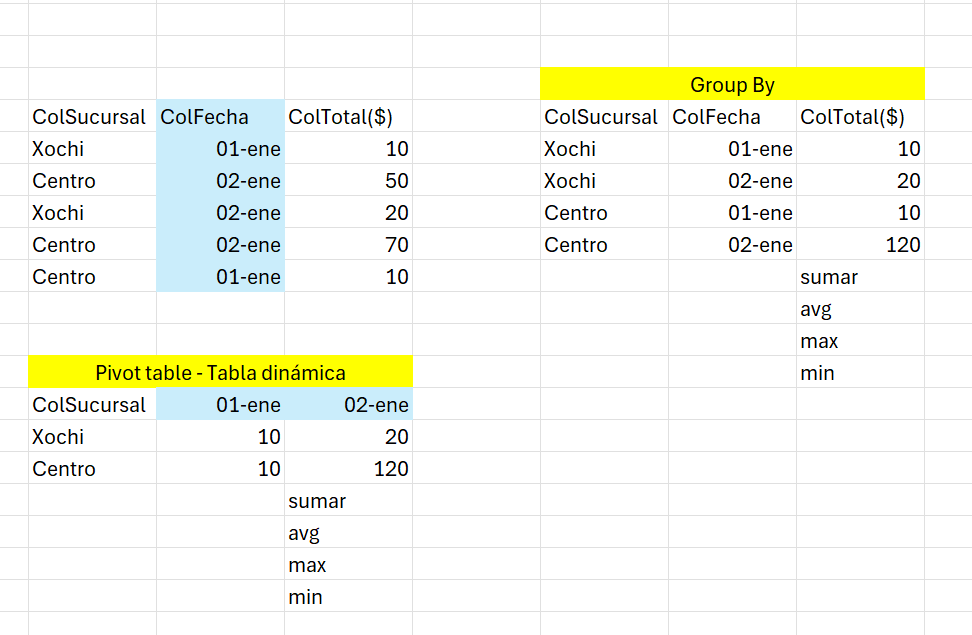

---

# **Itinerario de clase**

## Desglose Tabla dinámica

In [5]:
######################################
# Paso 1: Columna nueva con CASE_WHEN
#   |
#   ---> Solo ColTotal para
######################################
query = """
SELECT
  ColSucursal,
  ColFecha,

  CASE
    WHEN ColFecha = '2026-01-01' THEN ColTotal
    ELSE 0
  END AS PASO_1

FROM Consol_Ventas
"""

consulta(query)

,ColSucursal,ColFecha,PASO_1
0,Xochimilco,2026-01-01,38942.67
1,Cuemanco,2026-01-01,90862.80
2,Centro Histórico,2026-01-01,70629.15
3,Coyoacán,2026-01-01,6503.83
4,Xochimilco,2026-01-01,26057.50
...,...,...,...
580638,San Ángel,2026-01-31,0.00
580639,Coyoacán,2026-01-31,0.00
580640,Santa Fe,2026-01-31,0.00
580641,La Condesa,2026-01-31,0.00


In [7]:
######################################
# Paso 2:
#   |
#   ---> Agrupar po fecha y calcular
#        el total del PASO_1
######################################
query = """
SELECT
  ColSucursal,

  SUM(
    CASE
      WHEN ColFecha = '2026-01-01' THEN ColTotal
      ELSE 0
    END
  ) AS SUMA_PASO_1


FROM Consol_Ventas

GROUP BY
  ColSucursal
"""

consulta(query)

,ColSucursal,SUMA_PASO_1
0,Centro Histórico,6.984363e+08
1,Coyoacán,6.813953e+08
2,Cuemanco,6.673729e+08
3,La Condesa,6.746487e+08
4,Polanco,6.828641e+08
5,Reforma,6.842676e+08
6,San Ángel,6.553777e+08
7,Santa Fe,6.813506e+08
8,Tlalpan,6.517213e+08
9,Xochimilco,6.680474e+08


Como `PASO_1` solo tiene el total del `2026-01-01` y para el resto de fechas es 0, entonces la tabla anterior nos da el total de ventas para `2026-01-01` por sucursal, esto es

In [12]:
query = """
SELECT
  ColSucursal,

  SUM(
    CASE
      WHEN ColFecha = '2026-01-01' THEN ColTotal
      ELSE 0
    END
  ) AS 'Total 2026-01-01'


FROM Consol_Ventas

GROUP BY
  ColSucursal
"""

consulta(query)

,ColSucursal,Total 2026-01-01
0,Centro Histórico,6.984363e+08
1,Coyoacán,6.813953e+08
2,Cuemanco,6.673729e+08
3,La Condesa,6.746487e+08
4,Polanco,6.828641e+08
5,Reforma,6.842676e+08
6,San Ángel,6.553777e+08
7,Santa Fe,6.813506e+08
8,Tlalpan,6.517213e+08
9,Xochimilco,6.680474e+08


Podemos repetir proceso para más fechas

In [15]:
# y listo, tenemos ya nuestra tabla dinámica
query = """
SELECT
  ColSucursal,

  SUM(
    CASE
      WHEN ColFecha = '2026-01-01' THEN ColTotal
      ELSE 0
    END
  ) AS 'Total 2026-01-01',

  SUM(
    CASE
      WHEN ColFecha = '2026-01-02' THEN ColTotal
      ELSE 0
    END
  ) AS 'Total 2026-01-02',

  SUM(
    CASE
      WHEN ColFecha = '2026-01-03' THEN ColTotal
      ELSE 0
    END
  ) AS 'Total 2026-01-03'

FROM Consol_Ventas

GROUP BY
  ColSucursal
"""

consulta(query)

,ColSucursal,Total 2026-01-01,Total 2026-01-02,Total 2026-01-03
0,Centro Histórico,6.984363e+08,5.662355e+08,4.828419e+08
1,Coyoacán,6.813953e+08,5.630789e+08,4.890638e+08
2,Cuemanco,6.673729e+08,5.553502e+08,5.376192e+08
3,La Condesa,6.746487e+08,5.478301e+08,5.010074e+08
4,Polanco,6.828641e+08,5.764331e+08,5.215617e+08
5,Reforma,6.842676e+08,5.601209e+08,5.053204e+08
6,San Ángel,6.553777e+08,5.825115e+08,5.015483e+08
7,Santa Fe,6.813506e+08,5.939251e+08,4.849567e+08
8,Tlalpan,6.517213e+08,5.828142e+08,5.058424e+08
9,Xochimilco,6.680474e+08,5.611532e+08,5.386370e+08


O de forma simplificada

In [16]:
####################################
# cuanto vendio cada sucursal al dia
####################################
query = """
SELECT
  ColSucursal,
  SUM(CASE WHEN ColFecha = '2026-01-01' THEN ColTotal ELSE 0 END) AS Enero_1,
  SUM(CASE WHEN ColFecha = '2026-01-02' THEN ColTotal ELSE 0 END) AS Enero_2,
  SUM(CASE WHEN ColFecha = '2026-01-03' THEN ColTotal ELSE 0 END) AS Enero_3
FROM Consol_Ventas
GROUP BY ColSucursal
"""

consulta(query)

,ColSucursal,Enero_1,Enero_2,Enero_3
0,Centro Histórico,6.984363e+08,5.662355e+08,4.828419e+08
1,Coyoacán,6.813953e+08,5.630789e+08,4.890638e+08
2,Cuemanco,6.673729e+08,5.553502e+08,5.376192e+08
3,La Condesa,6.746487e+08,5.478301e+08,5.010074e+08
4,Polanco,6.828641e+08,5.764331e+08,5.215617e+08
5,Reforma,6.842676e+08,5.601209e+08,5.053204e+08
6,San Ángel,6.553777e+08,5.825115e+08,5.015483e+08
7,Santa Fe,6.813506e+08,5.939251e+08,4.849567e+08
8,Tlalpan,6.517213e+08,5.828142e+08,5.058424e+08
9,Xochimilco,6.680474e+08,5.611532e+08,5.386370e+08


In [24]:
####################################
# Todas las columnas del pivot
# potenciado con IA
####################################
query_1 = """
SELECT
    GROUP_CONCAT(
        'SUM(CASE WHEN ColFecha = ''' || ColFecha ||
        ''' THEN ColTotal ELSE 0 END) AS "' ||
        ColFecha || '"',
        ', '
    ) AS columnas
FROM (
    SELECT DISTINCT ColFecha
    FROM Consol_Ventas
    ORDER BY ColFecha
);
"""

columnas = consulta(query_1)
columnas_sql = columnas.loc[0, "columnas"]

# ----------------------------------------------------
# ----------------------------------------------------

query_2 = f"""
SELECT
    ColSucursal,
    {columnas_sql}
FROM Consol_Ventas
GROUP BY ColSucursal
ORDER BY ColSucursal;
"""

consulta(query_2)

,ColSucursal,2026-01-01,2026-01-02,2026-01-03,2026-01-04,2026-01-05,2026-01-06,2026-01-07,2026-01-08,2026-01-09,...,2026-01-22,2026-01-23,2026-01-24,2026-01-25,2026-01-26,2026-01-27,2026-01-28,2026-01-29,2026-01-30,2026-01-31
0,Centro Histórico,6.984363e+08,5.662355e+08,4.828419e+08,5.761396e+08,3.821349e+08,5.688275e+08,8.010864e+08,5.196941e+08,2.102630e+08,...,9.789606e+07,1.080104e+08,7.961302e+08,8.246786e+08,6.291415e+08,8.462917e+08,3.026654e+08,2.055078e+08,2.260585e+08,4.776496e+08
1,Coyoacán,6.813953e+08,5.630789e+08,4.890638e+08,5.811732e+08,3.822494e+08,5.822483e+08,8.307605e+08,5.041872e+08,2.106626e+08,...,1.049079e+08,1.010271e+08,8.669979e+08,8.192391e+08,6.722813e+08,8.087925e+08,3.118364e+08,2.002323e+08,2.553433e+08,4.841616e+08
2,Cuemanco,6.673729e+08,5.553502e+08,5.376192e+08,5.518044e+08,3.816533e+08,5.711930e+08,8.256179e+08,4.796190e+08,1.865185e+08,...,1.015746e+08,1.099266e+08,8.683202e+08,8.035504e+08,6.667435e+08,8.334371e+08,3.392136e+08,2.182182e+08,2.341541e+08,4.522900e+08
3,La Condesa,6.746487e+08,5.478301e+08,5.010074e+08,5.764184e+08,3.919596e+08,6.065068e+08,8.450340e+08,5.050726e+08,1.963410e+08,...,1.137778e+08,1.025967e+08,8.656283e+08,8.270659e+08,6.404092e+08,8.296296e+08,3.220315e+08,2.144068e+08,2.423924e+08,4.710178e+08
4,Polanco,6.828641e+08,5.764331e+08,5.215617e+08,5.320256e+08,3.896748e+08,5.736635e+08,8.356727e+08,4.883959e+08,2.079299e+08,...,1.072110e+08,9.983031e+07,8.227514e+08,7.707173e+08,6.517177e+08,8.866286e+08,3.159220e+08,2.009535e+08,2.497139e+08,4.683381e+08
5,Reforma,6.842676e+08,5.601209e+08,5.053204e+08,6.040390e+08,3.583132e+08,5.500286e+08,8.125231e+08,4.918297e+08,2.030375e+08,...,9.801359e+07,1.074387e+08,8.668333e+08,7.618583e+08,6.445940e+08,8.724562e+08,3.280534e+08,2.153717e+08,2.346344e+08,4.574179e+08
6,San Ángel,6.553777e+08,5.825115e+08,5.015483e+08,5.704517e+08,4.106922e+08,6.006017e+08,8.571291e+08,5.073075e+08,1.833358e+08,...,9.487454e+07,1.017794e+08,8.476348e+08,7.451999e+08,6.443996e+08,8.449830e+08,3.094189e+08,2.095477e+08,2.229699e+08,4.548082e+08
7,Santa Fe,6.813506e+08,5.939251e+08,4.849567e+08,5.847657e+08,3.709050e+08,5.864943e+08,8.581718e+08,5.353673e+08,1.911355e+08,...,8.738549e+07,1.015944e+08,8.357793e+08,7.629211e+08,6.144933e+08,8.566919e+08,3.207654e+08,2.232509e+08,2.279641e+08,4.486764e+08
8,Tlalpan,6.517213e+08,5.828142e+08,5.058424e+08,5.642574e+08,3.810906e+08,5.822695e+08,8.703147e+08,5.077391e+08,2.033596e+08,...,9.271984e+07,1.060116e+08,8.275044e+08,7.756497e+08,6.389660e+08,8.765226e+08,3.306989e+08,2.089148e+08,2.273129e+08,4.777896e+08
9,Xochimilco,6.680474e+08,5.611532e+08,5.386370e+08,5.733352e+08,3.705589e+08,5.569850e+08,8.343418e+08,4.784212e+08,2.012575e+08,...,9.337156e+07,1.183297e+08,8.275281e+08,8.029340e+08,6.365576e+08,8.714570e+08,3.509977e+08,2.133891e+08,2.290451e+08,4.553339e+08




## Proyecto final del curso

In [25]:
import sys

sys.path.append(
    "/content/drive/MyDrive/PyM-Cursos/Logística Cursos/_Curso SQL"
)

import pym

---

Extras:

* `COALESCE(valor1, valor2, valor3)`: Devuelve el primer valor que no sea nulo
* `substr(texto, posición_inicial, cantidad_de_caracteres)`: Extrae una parte de una cadena de texto

---

## Consultas finales

* Ventas mensuales por sucursal y cumplimiento de meta

In [ ]:
query = """
WITH ventas_mes AS (
    SELECT
        v.ColSucursal,
        c.Zona,
        substr(v.ColFecha, 1, 7) AS Mes,
        SUM(v.ColTotal) AS Ingreso,
        COUNT(*) AS Tickets
    FROM Consol_Ventas AS v
    LEFT JOIN Cat_Sucursales AS c
        USING (ColSucursal)
    WHERE v.ColFecha BETWEEN '2026-01-01' AND '2026-03-31'
    GROUP BY
        v.ColSucursal,
        c.Zona,
        substr(v.ColFecha, 1, 7)
),

pivot_sucursal AS (
    SELECT
        ColSucursal,
        Zona,

        SUM(CASE
            WHEN Mes = '2026-01' THEN Ingreso
            ELSE 0
        END) AS Enero,

        SUM(CASE
            WHEN Mes = '2026-02' THEN Ingreso
            ELSE 0
        END) AS Febrero,

        SUM(CASE
            WHEN Mes = '2026-03' THEN Ingreso
            ELSE 0
        END) AS Marzo,

        SUM(Ingreso) AS IngresoTrimestre,
        SUM(Tickets) AS TicketsTrimestre

    FROM ventas_mes
    GROUP BY ColSucursal, Zona
),

reporte AS (
    SELECT
        c.ColSucursal,
        c.Zona,
        c.MetaMensual,

        COALESCE(p.Enero, 0) AS Enero,
        COALESCE(p.Febrero, 0) AS Febrero,
        COALESCE(p.Marzo, 0) AS Marzo,
        COALESCE(p.IngresoTrimestre, 0) AS IngresoTrimestre,
        COALESCE(p.TicketsTrimestre, 0) AS TicketsTrimestre

    FROM Cat_Sucursales AS c
    LEFT JOIN pivot_sucursal AS p
        USING (ColSucursal)
)

SELECT
    ColSucursal,
    Zona,

    ROUND(MetaMensual / 1000000.0, 2) AS MetaMensual_MDP,
    ROUND(Enero / 1000000.0, 2) AS Enero_MDP,
    ROUND(Febrero / 1000000.0, 2) AS Febrero_MDP,
    ROUND(Marzo / 1000000.0, 2) AS Marzo_MDP,

    ROUND(
        Enero / NULLIF(MetaMensual, 0) * 100,
        1
    ) AS Cumplimiento_Enero,

    CASE
        WHEN Enero >= MetaMensual THEN 'Cumplida'
        WHEN Enero >= MetaMensual * 0.80 THEN 'En riesgo'
        ELSE 'Pendiente'
    END AS Estado_Enero,

    TicketsTrimestre

FROM reporte
ORDER BY Cumplimiento_Enero DESC;
"""

consulta(query)

,ColSucursal,Zona,MetaMensual_MDP,Enero_MDP,Febrero_MDP,Marzo_MDP,Cumplimiento_Enero,Estado_Enero,TicketsTrimestre
0,Xochimilco,Sur,4.8,14707.98,0.0,0.0,306416.2,Cumplida,58123
1,Cuemanco,Sur,5.0,14662.40,0.0,0.0,293248.0,Cumplida,58124
2,Tlalpan,Sur,5.8,14726.49,0.0,0.0,253905.0,Cumplida,58285
3,La Condesa,Centro,6.0,14699.38,0.0,0.0,244989.7,Cumplida,58053
4,San Ángel,Sur,6.2,14528.24,0.0,0.0,234326.5,Cumplida,57418
5,Coyoacán,Sur,6.5,14789.84,0.0,0.0,227535.9,Cumplida,58269
6,Santa Fe,Poniente,7.0,14687.29,0.0,0.0,209818.4,Cumplida,58216
7,Polanco,Poniente,7.5,14754.82,0.0,0.0,196730.9,Cumplida,58083
8,Centro Histórico,Centro,8.0,14583.20,0.0,0.0,182290.1,Cumplida,57966
9,Reforma,Centro,8.5,14671.07,0.0,0.0,172600.9,Cumplida,58106


* Rendimiento mensual por cajero

In [ ]:
query = """
WITH ventas_clasificadas AS (
    SELECT
        ColCajero,
        substr(ColFecha, 1, 7) AS Mes,
        ColTotal,

        CASE
            WHEN ColTotal >= 10000 THEN 'Alto'
            WHEN ColTotal >= 3000 THEN 'Medio'
            ELSE 'Bajo'
        END AS NivelTicket

    FROM Consol_Ventas
    WHERE ColFecha BETWEEN '2026-01-01' AND '2026-03-31'
),

resumen_cajeros AS (
    SELECT
        ColCajero,
        COUNT(*) AS Tickets,
        SUM(ColTotal) AS IngresoTotal,
        AVG(ColTotal) AS TicketPromedio,

        SUM(CASE
            WHEN Mes = '2026-01' THEN ColTotal
            ELSE 0
        END) AS Enero,

        SUM(CASE
            WHEN Mes = '2026-02' THEN ColTotal
            ELSE 0
        END) AS Febrero,

        SUM(CASE
            WHEN Mes = '2026-03' THEN ColTotal
            ELSE 0
        END) AS Marzo,

        SUM(CASE
            WHEN NivelTicket = 'Alto' THEN 1
            ELSE 0
        END) AS TicketsAltos

    FROM ventas_clasificadas
    GROUP BY ColCajero
),

metricas AS (
    SELECT
        *,
        TicketsAltos * 100.0 / NULLIF(Tickets, 0)
            AS PorcentajeTicketsAltos
    FROM resumen_cajeros
)

SELECT
    ColCajero,
    Tickets,

    ROUND(IngresoTotal / 1000000.0, 2)
        AS IngresoTotal_MDP,

    ROUND(TicketPromedio, 2)
        AS TicketPromedio,

    ROUND(Enero / 1000000.0, 2)
        AS Enero_MDP,

    ROUND(Febrero / 1000000.0, 2)
        AS Febrero_MDP,

    ROUND(Marzo / 1000000.0, 2)
        AS Marzo_MDP,

    ROUND(PorcentajeTicketsAltos, 1)
        AS PorcentajeTicketsAltos,

    CASE
        WHEN PorcentajeTicketsAltos >= 30
             AND TicketPromedio >= 5000
            THEN 'Sobresaliente'

        WHEN PorcentajeTicketsAltos >= 15
             OR TicketPromedio >= 3000
            THEN 'Competente'

        ELSE 'Por fortalecer'
    END AS Evaluacion

FROM metricas
ORDER BY IngresoTotal DESC;
"""

consulta(query)

,ColCajero,Tickets,IngresoTotal_MDP,TicketPromedio,Enero_MDP,Febrero_MDP,Marzo_MDP,PorcentajeTicketsAltos,Evaluacion
0,Carlos Alberto Mendoza Pérez,58210,14821.75,254625.49,14821.75,0.0,0.0,90.2,Sobresaliente
1,María Fernanda Castillo Reyes,58097,14773.21,254285.30,14773.21,0.0,0.0,90.6,Sobresaliente
2,Miguel Ángel Torres Hernández,58114,14764.61,254062.91,14764.61,0.0,0.0,90.5,Sobresaliente
3,Diana Carolina Salazar Ruiz,58300,14720.86,252501.91,14720.86,0.0,0.0,90.4,Sobresaliente
4,José Luis González Cruz,58500,14689.40,251100.88,14689.40,0.0,0.0,90.4,Sobresaliente
5,Valeria Jiménez Flores,57966,14683.49,253312.17,14683.49,0.0,0.0,90.5,Sobresaliente
6,Luis Fernando Ortega Díaz,58020,14618.96,251964.22,14618.96,0.0,0.0,90.4,Sobresaliente
7,Ana Sofía Morales García,57877,14592.10,252122.67,14592.10,0.0,0.0,90.5,Sobresaliente
8,Paola Alejandra Vargas León,57517,14574.02,253386.25,14574.02,0.0,0.0,90.4,Sobresaliente
9,Juan Carlos Ramírez López,58042,14572.30,251064.74,14572.30,0.0,0.0,90.3,Sobresaliente


* Rendimiento de productos por segmento de precio

In [ ]:
query = """
WITH productos_clasificados AS (
    SELECT
        ColProducto,
        substr(ColFecha, 1, 7) AS Mes,
        ColPrecio,
        ColCantidad,
        ColTotal,

        CASE
            WHEN ColPrecio >= 5000 THEN 'Premium'
            WHEN ColPrecio >= 1000 THEN 'Medio'
            ELSE 'Economico'
        END AS SegmentoPrecio

    FROM Consol_Ventas
    WHERE ColFecha BETWEEN '2026-01-01' AND '2026-03-31'
),

resumen_productos AS (
    SELECT
        ColProducto,
        SegmentoPrecio,
        COUNT(*) AS Operaciones,
        SUM(ColCantidad) AS Unidades,
        SUM(ColTotal) AS Ingreso,
        AVG(ColPrecio) AS PrecioPromedio,

        SUM(CASE
            WHEN Mes = '2026-01' THEN ColTotal
            ELSE 0
        END) AS Enero,

        SUM(CASE
            WHEN Mes = '2026-02' THEN ColTotal
            ELSE 0
        END) AS Febrero,

        SUM(CASE
            WHEN Mes = '2026-03' THEN ColTotal
            ELSE 0
        END) AS Marzo

    FROM productos_clasificados
    GROUP BY
        ColProducto,
        SegmentoPrecio

    HAVING COUNT(*) >= 100
)

SELECT
    ColProducto,
    SegmentoPrecio,
    Operaciones,
    Unidades,

    ROUND(PrecioPromedio, 2)
        AS PrecioPromedio,

    ROUND(Ingreso / 1000000.0, 2)
        AS Ingreso_MDP,

    ROUND(Enero / 1000000.0, 2)
        AS Enero_MDP,

    ROUND(Febrero / 1000000.0, 2)
        AS Febrero_MDP,

    ROUND(Marzo / 1000000.0, 2)
        AS Marzo_MDP,

    CASE
        WHEN Unidades >= 1000
             AND PrecioPromedio < 1000
            THEN 'Alto volumen'

        WHEN Ingreso >= 1000000
            THEN 'Alto valor'

        ELSE 'Desempeño estándar'
    END AS TipoProducto

FROM resumen_productos
ORDER BY Ingreso DESC;
"""

consulta(query)

* Perfil de ventas por zona

In [ ]:
query = """
WITH ventas_clasificadas AS (
    SELECT
        c.Zona,
        v.ColSucursal,
        substr(v.ColFecha, 1, 7) AS Mes,
        v.ColTotal,

        CASE
            WHEN v.ColTotal >= 10000 THEN 'Alto'
            WHEN v.ColTotal >= 3000 THEN 'Medio'
            ELSE 'Bajo'
        END AS TipoTicket

    FROM Consol_Ventas AS v
    INNER JOIN Cat_Sucursales AS c
        USING (ColSucursal)

    WHERE v.ColFecha BETWEEN '2026-01-01' AND '2026-03-31'
),

resumen_zonas AS (
    SELECT
        Zona,
        COUNT(*) AS Tickets,
        SUM(ColTotal) AS Ingreso,

        SUM(CASE
            WHEN Mes = '2026-01' THEN ColTotal
            ELSE 0
        END) AS Enero,

        SUM(CASE
            WHEN Mes = '2026-02' THEN ColTotal
            ELSE 0
        END) AS Febrero,

        SUM(CASE
            WHEN Mes = '2026-03' THEN ColTotal
            ELSE 0
        END) AS Marzo,

        SUM(CASE
            WHEN TipoTicket = 'Alto' THEN 1
            ELSE 0
        END) AS TicketsAltos,

        SUM(CASE
            WHEN TipoTicket = 'Medio' THEN 1
            ELSE 0
        END) AS TicketsMedios,

        SUM(CASE
            WHEN TipoTicket = 'Bajo' THEN 1
            ELSE 0
        END) AS TicketsBajos

    FROM ventas_clasificadas
    GROUP BY Zona
    HAVING COUNT(*) >= 100
),

metricas AS (
    SELECT
        *,
        TicketsAltos * 100.0 / NULLIF(Tickets, 0)
            AS PorcentajeAltos
    FROM resumen_zonas
)

SELECT
    Zona,
    Tickets,

    ROUND(Ingreso / 1000000.0, 2)
        AS Ingreso_MDP,

    ROUND(Enero / 1000000.0, 2)
        AS Enero_MDP,

    ROUND(Febrero / 1000000.0, 2)
        AS Febrero_MDP,

    ROUND(Marzo / 1000000.0, 2)
        AS Marzo_MDP,

    TicketsAltos,
    TicketsMedios,
    TicketsBajos,

    ROUND(PorcentajeAltos, 1)
        AS PorcentajeAltos,

    CASE
        WHEN PorcentajeAltos >= 30
            THEN 'Zona de tickets altos'

        WHEN PorcentajeAltos >= 15
            THEN 'Zona mixta'

        ELSE 'Zona de tickets bajos'
    END AS PerfilZona

FROM metricas
ORDER BY Ingreso DESC;
"""

consulta(query)

,Zona,Tickets,Ingreso_MDP,Enero_MDP,Febrero_MDP,Marzo_MDP,TicketsAltos,TicketsMedios,TicketsBajos,PorcentajeAltos,PerfilZona
0,Sur,290219,73414.95,73414.95,0.0,0.0,262390,16810,11019,90.4,Zona de tickets altos
1,Centro,174125,43953.66,43953.66,0.0,0.0,157500,10084,6541,90.5,Zona de tickets altos
2,Poniente,116299,29442.11,29442.11,0.0,0.0,105041,6903,4355,90.3,Zona de tickets altos


* Comparación de ventas por quincena

In [ ]:
query = """
WITH ventas_quincena AS (
    SELECT
        v.ColSucursal,
        c.Zona,
        substr(v.ColFecha, 1, 7) AS Mes,

        CASE
            WHEN CAST(strftime('%d', v.ColFecha) AS INTEGER) <= 15
                THEN '1Q'
            ELSE '2Q'
        END AS Quincena,

        v.ColTotal

    FROM Consol_Ventas AS v
    INNER JOIN Cat_Sucursales AS c
        USING (ColSucursal)

    WHERE v.ColFecha BETWEEN '2026-01-01' AND '2026-02-28'
),

pivot_quincena AS (
    SELECT
        ColSucursal,
        Zona,

        SUM(CASE
            WHEN Mes = '2026-01'
                 AND Quincena = '1Q'
                THEN ColTotal
            ELSE 0
        END) AS Enero_1Q,

        SUM(CASE
            WHEN Mes = '2026-01'
                 AND Quincena = '2Q'
                THEN ColTotal
            ELSE 0
        END) AS Enero_2Q,

        SUM(CASE
            WHEN Mes = '2026-02'
                 AND Quincena = '1Q'
                THEN ColTotal
            ELSE 0
        END) AS Febrero_1Q,

        SUM(CASE
            WHEN Mes = '2026-02'
                 AND Quincena = '2Q'
                THEN ColTotal
            ELSE 0
        END) AS Febrero_2Q

    FROM ventas_quincena
    GROUP BY
        ColSucursal,
        Zona
),

reporte AS (
    SELECT
        *,
        Enero_2Q - Enero_1Q AS VariacionEnero,
        Febrero_2Q - Febrero_1Q AS VariacionFebrero
    FROM pivot_quincena
)

SELECT
    ColSucursal,
    Zona,

    ROUND(Enero_1Q / 1000000.0, 2)
        AS Enero_1Q_MDP,

    ROUND(Enero_2Q / 1000000.0, 2)
        AS Enero_2Q_MDP,

    ROUND(Febrero_1Q / 1000000.0, 2)
        AS Febrero_1Q_MDP,

    ROUND(Febrero_2Q / 1000000.0, 2)
        AS Febrero_2Q_MDP,

    ROUND(VariacionEnero / 1000000.0, 2)
        AS VariacionEnero_MDP,

    CASE
        WHEN VariacionEnero > 0
            THEN 'Crecimiento en segunda quincena'

        WHEN VariacionEnero < 0
            THEN 'Caída en segunda quincena'

        ELSE 'Sin cambio'
    END AS ComportamientoEnero

FROM reporte
ORDER BY VariacionEnero DESC;
"""

consulta(query)

,ColSucursal,Zona,Enero_1Q_MDP,Enero_2Q_MDP,Febrero_1Q_MDP,Febrero_2Q_MDP,VariacionEnero_MDP,ComportamientoEnero
0,Cuemanco,Sur,7896.62,6765.78,0.0,0.0,-1130.84,Caída en segunda quincena
1,Coyoacán,Sur,7995.17,6794.67,0.0,0.0,-1200.50,Caída en segunda quincena
2,Xochimilco,Sur,7960.96,6747.01,0.0,0.0,-1213.95,Caída en segunda quincena
3,Polanco,Poniente,8025.51,6729.31,0.0,0.0,-1296.20,Caída en segunda quincena
4,Reforma,Centro,7986.04,6685.03,0.0,0.0,-1301.00,Caída en segunda quincena
5,Centro Histórico,Centro,7967.63,6615.57,0.0,0.0,-1352.06,Caída en segunda quincena
6,La Condesa,Centro,8042.04,6657.34,0.0,0.0,-1384.69,Caída en segunda quincena
7,Tlalpan,Sur,8057.51,6668.98,0.0,0.0,-1388.53,Caída en segunda quincena
8,San Ángel,Sur,7978.72,6549.53,0.0,0.0,-1429.19,Caída en segunda quincena
9,Santa Fe,Poniente,8090.37,6596.92,0.0,0.0,-1493.44,Caída en segunda quincena
